# Further Investigations into Anomalous Pressure Gradients & EPEs
*Written by: Adam Morgan*

*Last Updated April 17, 2026*

In [1]:
import cartopy.crs as ccrs
import cftime
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.stats as spstats
import xarray as xr

# Homemade routines
from ep_processing import *
from utils.visualization import draw_global_map, process_for_map

Loading the data from a default CMIP6-AMIP run...

In [2]:
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_generic_file_path = "_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
my_pr_file_path = "pr" + my_generic_file_path
my_ps_file_path = "ps" + my_generic_file_path

my_experiment_name = "amip"
my_runid = "agm-amip-test"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Daily surface pressure (obtained by post-processing/downsampling model outputs)
ds_ps_daily = get_ds(
        "ps",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_ps_file_path,
)

# Daily precipitation 
ds_pr_daily = get_ds(
        "pr",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_pr_file_path,
)

In [4]:
# Get the land fraction map
my_lf_path = "sftlf_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

ds_lf = get_ds_areacell(
                    my_runid, 
                    my_experiment_name,
                    base_path = my_base_path,
                    areacell_path = my_lf_path,
)

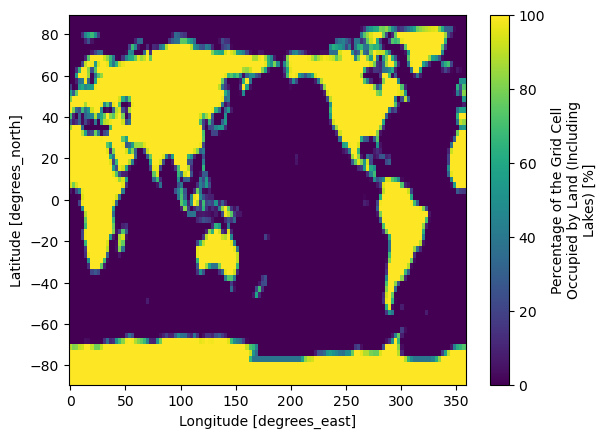

In [5]:
ds_lf.sftlf.plot()

In [6]:
da_lf = ds_lf.sftlf

We really want to avoid coastal effects on the pressure gradient, so we use a very strict land mask. 

In [7]:
land_mask = da_lf.where(da_lf >= 50, other = False).astype(bool)

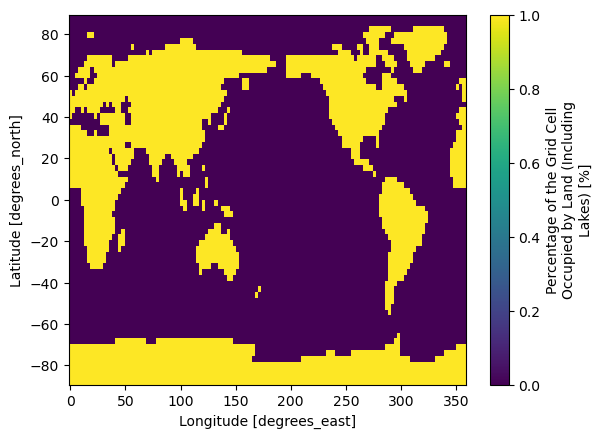

In [8]:
land_mask.plot()

In [9]:
da_ps_daily_land = ds_ps_daily.ps.where(land_mask).sel(lat  = slice(-60, 60))
da_ps_daily_ocean = ds_ps_daily.ps.where(~land_mask).sel(lat  = slice(-60, 60))
# thanks to Gemini for the syntax help here...for some reason xarray prefers `~` to `!` or `not`?

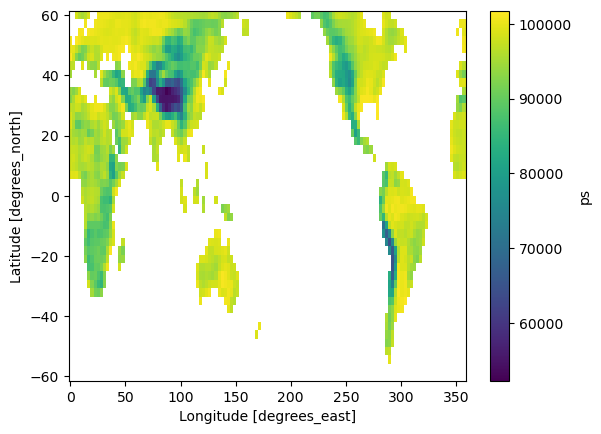

In [10]:
da_ps_daily_land.mean(dim = "time").plot()

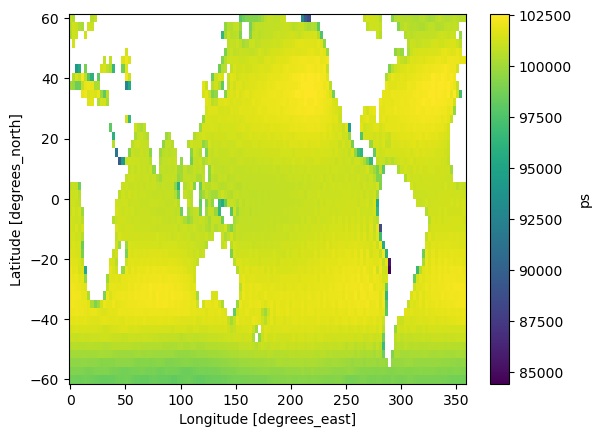

In [11]:
da_ps_daily_ocean.mean(dim = "time").plot()

As a final preprocessing stage, we dump the "hours" from the timestamps. 

In [12]:
#da_ps_daily_ocean = da_ps_daily_ocean.resample(time='1D').first()
da_ps_daily_ocean['time'] = da_ps_daily_ocean.time.dt.floor('D')

Determine the surface pressure gradient's magnitude as a function of space and time with a helper method I wrote. 

In [13]:
da_grad_ps = get_abs_horiz_gradient(da_ps_daily_ocean) # ds_ps_daily.ps

In [14]:
da_grad_ps.units

'Pa/km'

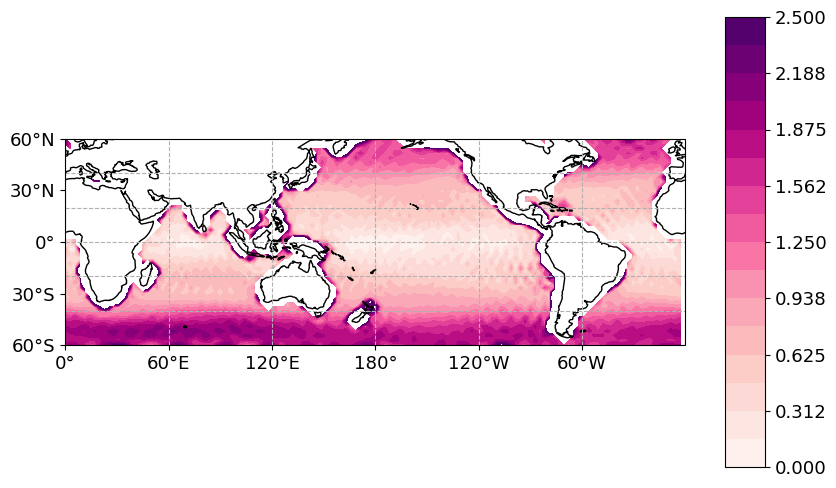

In [15]:
draw_global_map(
    da_grad_ps.lon,
    da_grad_ps.lat,
    da_grad_ps.mean(dim = "time").values,
    title = None,
    filled = True,
    show_fig = True,
    save_fig = False,
    levels = 16,
    cmap = "RdPu",
    cbar_params = [0.95, 0.12, 0.05, 0.75],
    bbox = [0, 360, -60, 60],
    vmin = 0,
    vmax = 2.5,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    # outfilename = "my_map" + ".png",
)

In [16]:
da_grad_ps.max()

<xarray.DataArray ()> Size: 8B
array(54.01986694)

# Comparison to Climatology

In [17]:
da_pr_daily_trimmed = ds_pr_daily.pr.where(~land_mask).sel(lat  = slice(-60, 60)).resample(time='1D').first()
da_pr_daily_trimmed = da_pr_daily_trimmed.fillna(-9999999999) # avoids dealing with NaN's and cftime.DateTime's in the same array!

In [18]:
grad_ps_anom_as_temporal_list = []

da_grad_ps_temporal_mean = da_grad_ps.mean(dim = "time")

for year in year_range:
    day_of_epe = select_fixed_year(da_pr_daily_trimmed, year).idxmax(dim = "time")
    anom_current_year = (
        (
            da_grad_ps.sel(time = day_of_epe) - da_grad_ps_temporal_mean
        ) # / da_grad_ps_temporal_mean
    )
    grad_ps_anom_as_temporal_list.append(anom_current_year)

da_grad_ps_anom = xr.DataArray(
        data = grad_ps_anom_as_temporal_list,
        dims = ["time", "lat", "lon"],
        coords = dict(
            lon = da_grad_ps.lon.to_numpy(),
            lat = da_grad_ps.lat.to_numpy(),
            time = [year for year in year_range],
        ),
)

In [19]:
def threshold_da(da, threshold):
    return da.where(da <= threshold, other = threshold).where(da >= -threshold, other = -threshold)

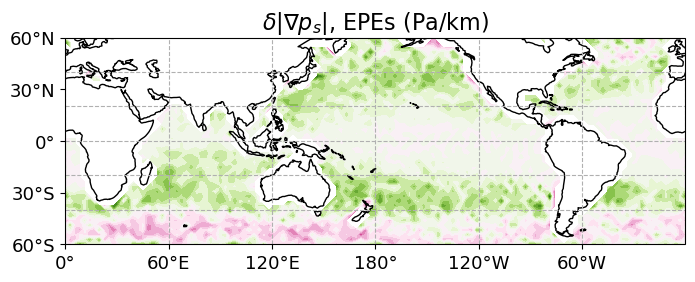

In [20]:
field_vals, lon_plt, lat_plt = process_for_map(da_grad_ps_anom.mean(dim = "time"))

draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"$\delta|\nabla p_s|$, EPEs (Pa/km)",
    filled = True,
    show_fig = True,
    save_fig = True,
    levels = 16,
    cmap = "PiYG",
    cbar_params = [0.95, 0.33, 0.05, 0.325],
    bbox = [0, 360, -60, 60],
    vmin = -1.6,
    vmax = 1.6,
    draw_labels = False,
    label_contours = False,
    remove_cbar = True,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    outfilename = "global_pressure_gradient_anomaly_epes" + ".png",
)

To make sure the anomalies we're seeing are actually associated with EPEs and not occurring "by chance alone", we can compare them to the anomalies taken on *uniformly random days*. 

In [21]:
np.random.seed(32)
rng = np.random.default_rng()
random_date_indices = rng.integers(
    low = 0, 
    high = len(da_grad_ps.time), 
    size = (len(da_grad_ps.lat) , len(da_grad_ps.lon)),
)  

In [22]:
random_dates = xr.DataArray(
    data = [da_grad_ps.time[random_date_index] for random_date_index in random_date_indices],
    dims = ["lat", "lon"],
    coords = dict(
            lon = da_grad_ps.lon.to_numpy(),
            lat = da_grad_ps.lat.to_numpy(),
    ),
)

In [23]:
da_grad_ps_random_dates = da_grad_ps.sel(time = random_dates)

In [24]:
da_grad_ps_anom_random_dates = (da_grad_ps_random_dates - da_grad_ps_temporal_mean) # / da_grad_ps_temporal_mean
da_grad_ps_anom_random_dates = da_grad_ps_anom_random_dates.fillna(9999999)

In [25]:
field_vals, lon_plt, lat_plt = process_for_map(da_grad_ps_anom_random_dates)

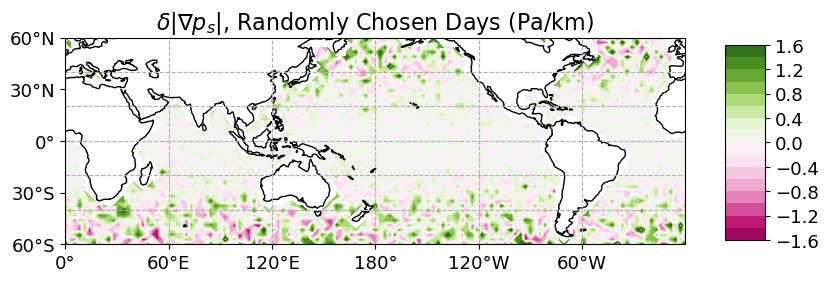

In [26]:
draw_global_map(
    lon_plt,
    lat_plt,
    field_vals,
    title = r"$\delta |\nabla p_s|$, Randomly Chosen Days (Pa/km)",
    filled = True,
    show_fig = True,
    save_fig = True,
    levels = 16,
    cmap = "PiYG",
    cbar_params = [0.95, 0.33, 0.05, 0.325],
    bbox = [0, 360, -60, 60],
    vmin = -1.6,
    vmax = 1.6,
    draw_labels = False,
    label_contours = False,
    remove_cbar = False,
    fig = None,
    projection = ccrs.PlateCarree(central_longitude=180),
    outfilename = "global_pressure_gradient_anomaly_random_days" + ".png",
)